In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('../../traffic.csv')
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [4]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['weekday'] = df['DateTime'].dt.weekday

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,weekday
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
 4   hour      48120 non-null  int32         
 5   day       48120 non-null  int32         
 6   month     48120 non-null  int32         
 7   weekday   48120 non-null  int32         
dtypes: datetime64[ns](1), int32(4), int64(3)
memory usage: 2.2 MB


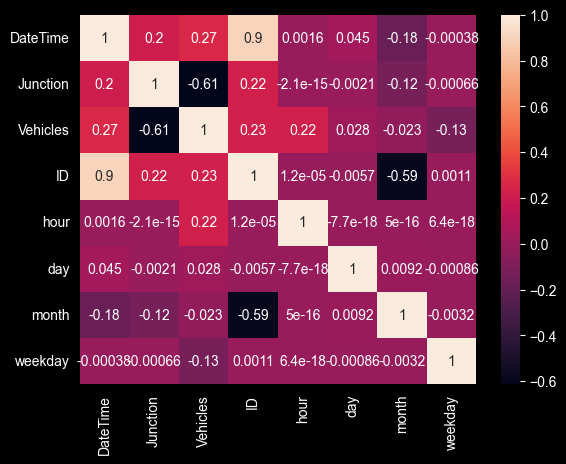

In [5]:
df.info()
df.describe()

sns.heatmap(df.corr(), annot=True)
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

X = df[['Junction', 'hour', 'day', 'month', 'weekday']]
y = df['Vehicles']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [7]:
print("For Test .....")
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2: ", r2)

print("For Train .....")
mae_train = mean_absolute_error(y_train,y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train,y_pred_train))
r2_trian = r2_score(y_train,y_pred_train)
print("MAE: ", mae_train)
print("RMSE: ", rmse_train)
print("R2: ", r2_trian)


For Test .....
MAE:  11.111573436200212
RMSE:  14.919815120121852
R2:  0.45380281764283004
For Train .....
MAE:  11.388790244347204
RMSE:  15.471350533070337
R2:  0.45133766233249195


In [8]:
df_exp = df.copy()
df_exp = df_exp.sort_values(by=["Junction","DateTime"])

df_exp["lag_1"] = df_exp.groupby("Junction")["Vehicles"].shift(1)
df_exp["lag_2"] = df_exp.groupby("Junction")["Vehicles"].shift(2)

df_exp = df_exp.dropna()

X_exp = df_exp[['Junction', 'hour', 'day', 'month', 'weekday','lag_1','lag_2']]
Y_exp = df_exp['Vehicles']

X_exp_scaled = scaler.fit_transform(X_exp)

X_exp_train, X_exp_test, Y_exp_train, Y_exp_test = train_test_split(X_exp_scaled, Y_exp, test_size=0.2, random_state=42, shuffle=False)


In [9]:
exp_model = LinearRegression()
exp_model.fit(X_exp_train, Y_exp_train)

y_exp_predict = exp_model.predict(X_exp_test)
y_exp_predict_train = exp_model.predict(X_exp_train)

print("For Test .....")
exp_mae = mean_absolute_error(Y_exp_test, y_exp_predict)
exp_rmse = np.sqrt(mean_squared_error(Y_exp_test, y_exp_predict))
exp_r2 = r2_score(Y_exp_test, y_exp_predict)
print("MAE: ", exp_mae)
print("RMSE: ", exp_rmse)
print("R2: ", exp_r2)

print("For Train .....")
exp_mae_train = mean_absolute_error(Y_exp_train, y_exp_predict_train)
exp_rmse_train = np.sqrt(mean_squared_error(Y_exp_train, y_exp_predict_train))
exp_r2_train = r2_score(Y_exp_train, y_exp_predict_train)
print("MAE: ", exp_mae_train)
print("RMSE: ", exp_rmse_train)
print("R2: ", exp_r2_train)


For Test .....
MAE:  3.1830255882289014
RMSE:  5.402564835120665
R2:  0.7061593074107095
For Train .....
MAE:  3.3019561594927964
RMSE:  4.850114267980292
R2:  0.9510936255349909


In [10]:
df_exp2 = df.copy()
df_exp2 = df_exp2.sort_values(by=["Junction","DateTime"])

df_exp2["lag_1"] = df_exp2.groupby("Junction")["Vehicles"].shift(1)
df_exp2["lag_2"] = df_exp2.groupby("Junction")["Vehicles"].shift(2)
df_exp2["lag_24"] = df_exp2.groupby("Junction")["Vehicles"].shift(24)

df_exp2 = df_exp2.dropna()

X_exp2 = df_exp2[['Junction', 'hour', 'day', 'month', 'weekday','lag_1','lag_2','lag_24']]
Y_exp2 = df_exp2['Vehicles']

X_exp2_train, X_exp2_test, Y_exp2_train, Y_exp2_test = train_test_split(X_exp2, Y_exp2, test_size=0.2, random_state=42, shuffle=False)

X_exp2_train_scaled = scaler.fit_transform(X_exp2_train)
X_exp2_test_scaled = scaler.transform(X_exp2_test)

In [11]:
exp2_model = LinearRegression()
exp2_model.fit(X_exp2_train_scaled, Y_exp2_train)

y_exp2_predict = exp2_model.predict(X_exp2_test_scaled)
y_exp2_predict_train = exp2_model.predict(X_exp2_train_scaled)

print("For Test .....")
exp2_mae = mean_absolute_error(Y_exp2_test, y_exp2_predict)
exp2_rmse = np.sqrt(mean_squared_error(Y_exp2_test, y_exp2_predict))
exp2_r2 = r2_score(Y_exp2_test, y_exp2_predict)
print("MAE: ", exp2_mae)
print("RMSE: ", exp2_rmse)
print("R2: ", exp2_r2)

print("For Train .....")
exp2_mae_train = mean_absolute_error(Y_exp2_train, y_exp2_predict_train)
exp2_rmse_train = np.sqrt(mean_squared_error(Y_exp2_train, y_exp2_predict_train))
exp2_r2_train = r2_score(Y_exp2_train, y_exp2_predict_train)
print("MAE: ", exp2_mae_train)
print("RMSE: ", exp2_rmse_train)
print("R2: ", exp2_r2_train)

For Test .....
MAE:  2.974869266306985
RMSE:  5.118491762791613
R2:  0.7362800173539675
For Train .....
MAE:  3.084377271689946
RMSE:  4.550207526097814
R2:  0.9569832077621849


In [12]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Find best alpha
ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}
grid = GridSearchCV(ridge, params, scoring='r2', cv=5)
grid.fit(X_exp2_train_scaled, Y_exp2_train)

print("Best alpha:", grid.best_params_)
best_ridge = grid.best_estimator_

# Evaluate
y_pred_test = best_ridge.predict(X_exp2_test_scaled)
y_pred_train = best_ridge.predict(X_exp2_train_scaled)

print("Test R²:", r2_score(Y_exp2_test, y_pred_test))
print("Train R²:", r2_score(Y_exp2_train, y_pred_train))

Best alpha: {'alpha': 100}
Test R²: 0.7379755026289474
Train R²: 0.9568650699280679


In [13]:
df_exp3 = df.copy()
df_exp3 = df_exp3.sort_values(by=["Junction", "DateTime"])

# Original lag features
df_exp3["lag_1"] = df_exp3.groupby("Junction")["Vehicles"].shift(1)
df_exp3["lag_2"] = df_exp3.groupby("Junction")["Vehicles"].shift(2)
df_exp3["lag_24"] = df_exp3.groupby("Junction")["Vehicles"].shift(24)

# New — rolling means
df_exp3["rolling_mean_3"] = df_exp3.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df_exp3["rolling_mean_24"] = df_exp3.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(24).mean()
)

df_exp3["is_rush_hour"] = df_exp3["hour"].isin([8, 9, 17, 18, 19]).astype(int)
df_exp3["is_weekend"] = (df_exp3["weekday"] >= 5).astype(int)

df_exp3 = df_exp3.dropna()

X_exp3 = df_exp3[['Junction', 'hour', 'day', 'month', 'weekday',
                   'lag_1', 'lag_2', 'lag_24',
                   'rolling_mean_3', 'rolling_mean_24',
                   'is_rush_hour', 'is_weekend']]
Y_exp3 = df_exp3['Vehicles']

# Split first, then scale
X_exp3_train, X_exp3_test, Y_exp3_train, Y_exp3_test = train_test_split(
    X_exp3, Y_exp3, test_size=0.2, random_state=42, shuffle=False
)

scaler3 = StandardScaler()  # use a fresh scaler
X_exp3_train_scaled = scaler3.fit_transform(X_exp3_train)
X_exp3_test_scaled = scaler3.transform(X_exp3_test)

# Model
exp3_model = LinearRegression()
exp3_model.fit(X_exp3_train_scaled, Y_exp3_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:

y_exp3_predict = exp3_model.predict(X_exp3_test_scaled)
y_exp3_predict_train = exp3_model.predict(X_exp3_train_scaled)

print("For Test .....")
exp3_mae = mean_absolute_error(Y_exp3_test, y_exp3_predict)
exp3_rmse = np.sqrt(mean_squared_error(Y_exp3_test, y_exp3_predict))
exp3_r2 = r2_score(Y_exp3_test, y_exp3_predict)
print("MAE: ", exp3_mae)
print("RMSE: ", exp3_rmse)
print("R2: ", exp3_r2)

print("For Train .....")
exp3_mae_train = mean_absolute_error(Y_exp3_train, y_exp3_predict_train)
exp3_rmse_train = np.sqrt(mean_squared_error(Y_exp3_train, y_exp3_predict_train))
exp3_r2_train = r2_score(Y_exp3_train, y_exp3_predict_train)
print("MAE: ", exp3_mae_train)
print("RMSE: ", exp3_rmse_train)
print("R2: ", exp3_r2_train)

For Test .....
MAE:  2.919298143387712
RMSE:  5.076041957284454
R2:  0.7406361599984657
For Train .....
MAE:  2.99733636893295
RMSE:  4.448395663913073
R2:  0.9588866911686991


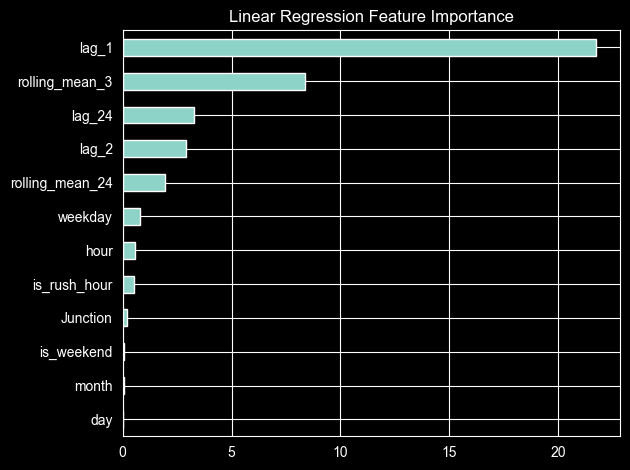

In [15]:
# Linear Regression feature importance via coefficients
feature_names = ['Junction', 'hour', 'day', 'month', 'weekday',
                 'lag_1', 'lag_2', 'lag_24',
                 'rolling_mean_3', 'rolling_mean_24',
                 'is_rush_hour', 'is_weekend']
lr_importance = pd.Series(
    np.abs(exp3_model.coef_),  # absolute value to see magnitude
    index=feature_names
)
lr_importance.sort_values().plot(kind='barh', title='Linear Regression Feature Importance')
plt.tight_layout()
plt.show()

In [16]:
import holidays as hd

df_exp4 = df.copy()
df_exp4 = df_exp4.sort_values(by=["Junction", "DateTime"])

# Lag features
df_exp4["lag_1"] = df_exp4.groupby("Junction")["Vehicles"].shift(1)
df_exp4["lag_2"] = df_exp4.groupby("Junction")["Vehicles"].shift(2)
df_exp4["lag_24"] = df_exp4.groupby("Junction")["Vehicles"].shift(24)

# Rolling means
df_exp4["rolling_mean_3"] = df_exp4.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df_exp4["rolling_mean_24"] = df_exp4.groupby("Junction")["Vehicles"].transform(
    lambda x: x.shift(1).rolling(24).mean()
)

# Holiday feature — calendar knowledge, not future data
us_holidays = hd.US()
df_exp4["is_holiday"] = df_exp4["DateTime"].dt.date.apply(
    lambda x: 1 if x in us_holidays else 0
)

# Rush hour and weekend
df_exp4["is_rush_hour"] = df_exp4["hour"].isin([8, 9, 17, 18, 19]).astype(int)
df_exp4["is_weekend"] = (df_exp4["weekday"] >= 5).astype(int)

df_exp4 = df_exp4.dropna()

X_exp4 = df_exp4[['Junction', 'hour', 'day', 'month', 'weekday',
                   'lag_1', 'lag_2', 'lag_24',
                   'rolling_mean_3', 'rolling_mean_24',
                   'is_holiday', 'is_rush_hour', 'is_weekend']]
Y_exp4 = df_exp4['Vehicles']

X_exp4_train, X_exp4_test, Y_exp4_train, Y_exp4_test = train_test_split(
    X_exp4, Y_exp4, test_size=0.2, random_state=42, shuffle=False
)

scaler4 = StandardScaler()
X_exp4_train_scaled = scaler4.fit_transform(X_exp4_train)
X_exp4_test_scaled = scaler4.transform(X_exp4_test)

exp4_model = LinearRegression()
exp4_model.fit(X_exp4_train_scaled, Y_exp4_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_exp4_predict = exp4_model.predict(X_exp4_test_scaled)
y_exp4_predict_train = exp4_model.predict(X_exp4_train_scaled)

print("For Test .....")
exp4_mae = mean_absolute_error(Y_exp4_test, y_exp4_predict)
exp4_rmse = np.sqrt(mean_squared_error(Y_exp4_test, y_exp4_predict))
exp4_r2 = r2_score(Y_exp4_test, y_exp4_predict)
print("MAE: ", exp4_mae)
print("RMSE: ", exp4_rmse)
print("R2: ", exp4_r2)

print("For Train .....")
exp4_mae_train = mean_absolute_error(Y_exp4_train, y_exp4_predict_train)
exp4_rmse_train = np.sqrt(mean_squared_error(Y_exp4_train, y_exp4_predict_train))
exp4_r2_train = r2_score(Y_exp4_train, y_exp4_predict_train)
print("MAE: ", exp4_mae_train)
print("RMSE: ", exp4_rmse_train)
print("R2: ", exp4_r2_train)

For Test .....
MAE:  2.9188203614366275
RMSE:  5.075618279216902
R2:  0.7406794544335915
For Train .....
MAE:  2.9977354092715065
RMSE:  4.4477948657554025
R2:  0.9588977959057902


In [18]:
# Check if any holidays were actually flagged
print("Total holiday hours:", df_exp4["is_holiday"].sum())

# See which dates were flagged
holiday_dates = df_exp4[df_exp4["is_holiday"] == 1]["DateTime"].dt.date.unique()
print("Holiday dates found:", holiday_dates)

Total holiday hours: 1464
Holiday dates found: [datetime.date(2015, 11, 11) datetime.date(2015, 11, 26)
 datetime.date(2015, 12, 25) datetime.date(2016, 1, 1)
 datetime.date(2016, 1, 18) datetime.date(2016, 2, 15)
 datetime.date(2016, 5, 30) datetime.date(2016, 7, 4)
 datetime.date(2016, 9, 5) datetime.date(2016, 10, 10)
 datetime.date(2016, 11, 11) datetime.date(2016, 11, 24)
 datetime.date(2016, 12, 25) datetime.date(2016, 12, 26)
 datetime.date(2017, 1, 1) datetime.date(2017, 1, 2)
 datetime.date(2017, 1, 16) datetime.date(2017, 2, 20)
 datetime.date(2017, 5, 29)]
